In [1]:
import numpy as np
from shapely import Polygon, LineString
from shapely.plotting import plot_polygon, plot_line
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
})
%matplotlib inline 

In [3]:
def sigmoid(x): return 1/(1+np.exp(-x))
def swish(x): return x*sigmoid(x)
def ReLU6(x): return min(max([0,x]),6)
def hswish(x): return x*ReLU6(x+3)/6 

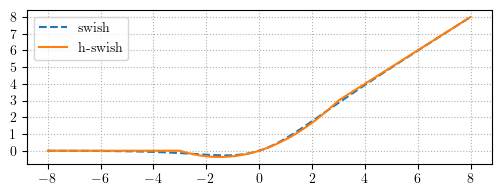

In [4]:
plt.figure(figsize=(6,2))
x = np.linspace(-8,8,100)
plt.plot(x,[swish(i) for i in x],'--',label='swish')
plt.plot(x, [hswish(i) for i in x],label='h-swish')
plt.grid(linestyle='dotted')
plt.yticks(range(9))
plt.legend()
plt.savefig('figures/hswish.pdf', bbox_inches='tight', pad_inches=0)

In [235]:
def insert_text_between_markers(filename, text):
    with open(filename, 'r') as f:
        lines = f.readlines()
    try: 
        start_idx = next(i for i, line in enumerate(lines) if '%START' in line)
        end_idx = next(i for i, line in enumerate(lines) if '%END' in line)
    except StopIteration: return
    new_lines = lines[:start_idx+1] + [text + '\n'] + lines[end_idx:]
    with open(filename, 'w') as f:
        f.writelines(new_lines)

class Draw:
    def __init__(self,a,b,type='--',prop=[]):
        self.a = a
        self.b = b
        self.type = type
        self.prop = ','.join(prop)
        
    def plot(self,ax):
        aX, aY = self.a
        bX, bY = self.b
        match self.type:
            case '--':
                ax.plot([self.a[0],self.b[0]],[self.a[1],self.b[1]],'-k')
            case 'rectangle':
                F = Polygon([self.a,(bX,aY),self.b,(aX,bY)])
                plot_polygon(F,ax,add_points=False,edgecolor='black',facecolor='white')

    def __repr__(self):
        return f'\\draw{"["+self.prop+"]" if self.prop else ''} {self.a} {self.type} {self.b};'

class Node:
    def __init__(self,coord,text='',name='',prop={}):
        self.coord = coord
        self.text = text
        self.name = name
        self.prop = prop
    
    def plot(self,ax): 
        plt.text(
            self.coord[0],self.coord[1],self.text,
            horizontalalignment='center',verticalalignment='center')

    def __repr__(self):
        name = f' ({self.name})'
        text = '{'+self.text+'}'
        propStr = ','.join([f'{key}{"=" if self.prop[key] else ""}{self.prop[key]}' for key in self.prop])
        return f'\\node{'['+propStr+']' if propStr else ''}{name if self.name else ""} at {self.coord} {text};'

class TikzPicture:
    def __init__(self,file):
        self.file = file
        self.elements = []

    def add(self, el): self.elements += [el]

    def plot(self,ax):
        for el in self.elements:
            plt.axis('equal')
            el.plot(ax)
    
    def write(self): insert_text_between_markers(self.file,self.__repr__())

    def __repr__(self):
        return '\t'+'\n\t'.join((e.__repr__() for e in self.elements))

In [100]:
colors = [f'color{i+1}' for i in range(8)]
def input_channels(TP,origin,lato,canali,H,gap,color='white',angolo=False,coloreAngolo=f'{colors[1]}!60'):
    oX, oY = origin
    gapX, gapY = gap
    for c in range(canali-1,-1,-1):
        a =      oX+gapX*c, oY+gapY*c
        b = oX+lato+gapX*c, oY+lato+gapY*c
        TP.add(Draw(a,b,'rectangle',prop=[f'fill={color}']))
        if H==0: continue
        step = lato/H
        if angolo:
            a =      oX+gapX*c+(H-1)*lato/H, oY+gapY*c+(H-1)*lato/H
            b = oX+gapX*c+step+(H-1)*lato/H, oY+gapY*c+(H-1)*lato/H+step
            TP.add(Draw(a,b,'rectangle',prop=[f'fill={coloreAngolo}']))
        for w in range(H+1):
            e =      oX+gapX*c, oY+gapY*c+w*step
            d = oX+lato+gapX*c, oY+gapY*c+w*step
            TP.add(Draw(e,d,'--'))
        for h in range(H+1):
            e = oX+gapX*c+h*step, oY+gapY*c
            d = oX+gapX*c+h*step, oY+gapY*c+lato
            TP.add(Draw(e,d,'--'))

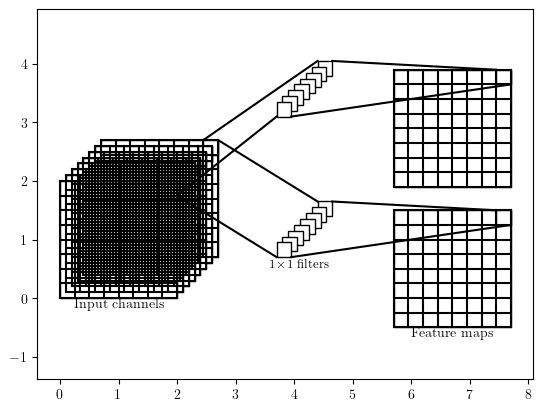

In [253]:
TP = TikzPicture('tikz/fire.tex')

oX, oY = (0,0)
lato = 2
canali = 8
H = 8
gap = 0.1,0.1

input_channels(TP,(oX,oY),lato,canali,H,gap,angolo=True,coloreAngolo=colors[3],color=colors[6]+'!60')
filterX = 3.7
filterYtop = 3.1
filterDistance = 2.4
filtSingleDist = 2
singleX = filterX+filtSingleDist
singleYtop = 1.9
input_channels(TP,(filterX,oX+filterYtop),lato/H,canali,0,gap,color=colors[1]+'!50')
input_channels(TP,(filterX,oX+filterYtop-filterDistance),lato/H,canali,0,gap,color=colors[2]+'!50')
input_channels(TP,(singleX,oY+singleYtop),lato,1,H,gap,  color=colors[1]+'!50',angolo=True,coloreAngolo=colors[3])
input_channels(TP,(singleX,oY+singleYtop-2.4),lato,1,H,gap,color=colors[2]+'!50',angolo=True,coloreAngolo=colors[3])

a = oX+lato, oY+(H-1)*lato/H
b = filterX, filterYtop
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = oX+lato+(canali-1)*gap[0]-lato/H, oY+(H-1)*lato/H+(canali-1)*gap[1]+lato/H
b = filterX+lato/H+(canali-1)*gap[0]-lato/H, filterYtop+(canali-1)*gap[1]+lato/H
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = filterX+lato/H, filterYtop
b = singleX+lato, singleYtop+(H-1)*lato/H
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = filterX+lato/H+(canali-1)*gap[0], filterYtop+(canali-1)*gap[1]+lato/H
b = singleX+lato-lato/H, singleYtop+lato
TP.add(Draw(a,b,'--',prop=['densely dashed']))

a = oX+lato, oY+(H-1)*lato/H
b = filterX, filterYtop-filterDistance
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = oX+lato+(canali-1)*gap[0], oY+(H-1)*lato/H+(canali-1)*gap[1]+lato/H
b = filterX+lato/H+(canali-1)*gap[0]-lato/H, filterYtop+(canali-1)*gap[1]+lato/H-filterDistance
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = filterX+lato/H, filterYtop-filterDistance
b = singleX+lato, singleYtop+(H-1)*lato/H-filterDistance
TP.add(Draw(a,b,'--',prop=['densely dashed']))
a = filterX+lato/H+(canali-1)*gap[0], filterYtop+(canali-1)*gap[1]+lato/H-filterDistance
b = singleX+lato-lato/H, singleYtop+lato-filterDistance
TP.add(Draw(a,b,'--',prop=['densely dashed']))

TP.add(Node((oX+lato/2,oY-0.1),text='Input channels',prop={'below':''}))
TP.add(Node((filterX+canali*gap[0]/2,filterYtop-filterDistance-0.1),text='\\small$1\\!\\times\\!1$ filters',prop={'below':''}))
TP.add(Node((singleX+lato/2,singleYtop-filterDistance-0.1),text='Feature maps',prop={'below':''}))

TP.write()
TP.plot(plt.gca())